# Load Dataset

In [1]:
import pandas as pd
df = pd.read_csv('creditcard.csv')

# EDA

In [2]:
df.shape

(284807, 31)

In [3]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df['Class'].head(25)

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
Name: Class, dtype: int64

In [6]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [7]:
correlations = df.corr()['Class'].sort_values(ascending=False)
print(correlations)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [8]:
df.groupby('Class')['Amount'].mean()

Class
0     88.291022
1    122.211321
Name: Amount, dtype: float64

<Axes: title={'center': 'Amount'}, xlabel='Class'>

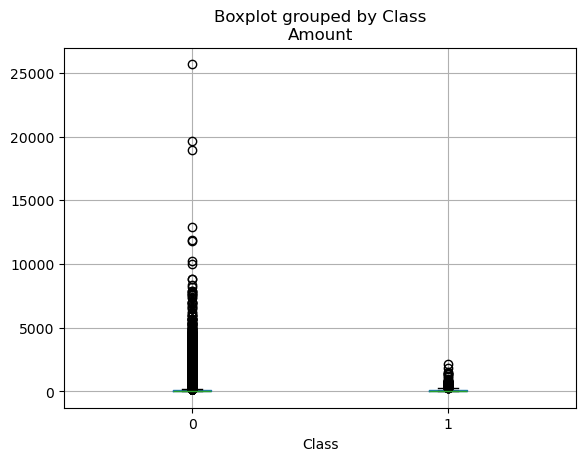

In [9]:
#outlier amount(very large amount can be a fraud)
df['Amount'].describe()
df.boxplot(column='Amount', by='Class')

In [10]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
284802    False
284803    False
284804    False
284805    False
284806    False
Length: 284807, dtype: bool

# Data Cleaning

In [11]:
df = df.drop_duplicates()

In [12]:
df.shape

(283726, 31)

In [13]:
#no need to drop time
df.groupby('Class')['Time'].mean()

Class
0    94835.058093
1    80450.513742
Name: Time, dtype: float64

In [14]:
#no need to drop as there is no null row / col
#df.dropna()

In [15]:
# Features and target
X = df.drop('Class', axis=1)   
y = df['Class']              

# Split data

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [17]:
X_val.shape

(42559, 30)

In [18]:
X_train.shape

(198608, 30)

In [19]:
X_test.shape

(42559, 30)

# Scaling Features

In [20]:
#V1–V28 are already PCA-transformed
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_val[['Time', 'Amount']] = scaler.transform(X_val[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

# Baseline Neural Network

In [21]:
import tensorflow as tf
from tensorflow import keras

model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1)  
])

model.compile(
    optimizer='adam',
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256
)

Epoch 1/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.0388 - val_loss: 0.0046
Epoch 2/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 3/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0033 - val_loss: 0.0037
Epoch 4/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0030 - val_loss: 0.0036
Epoch 5/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0029 - val_loss: 0.0035
Epoch 6/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0027 - val_loss: 0.0035
Epoch 7/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0026 - val_loss: 0.0035
Epoch 8/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0025 - val_loss: 0.0035
Epoch 9/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0023 - val_loss: 0.0034
Epoch 10/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0022 - val_loss: 0.0033


In [22]:
# Finding prediction for this baselien NN
y_pred_probs = tf.sigmoid(model.predict(X_test)).numpy()
y_pred = (y_pred_probs > 0.5).astype(int)

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


In [23]:
import pandas as pd

comparison = pd.DataFrame({
    "Actual": y_test[:20],
    "Predicted": y_pred[:20].flatten()
})

print(comparison)

        Actual  Predicted
249239       1          0
134142       0          0
114515       0          0
280522       0          0
180964       0          0
82329        0          0
158157       0          0
167431       0          0
225113       0          0
44043        0          0
80397        0          0
14684        0          0
191722       0          0
1768         0          0
279933       0          0
269056       0          0
4693         0          0
56710        0          0
151733       0          0
67246        0          0


# Bias/Variance Diagnostic 

In [24]:
train_loss = history.history['loss'][-1]
val_loss = history.history['val_loss'][-1]     

In [25]:
print("Training Loss:", train_loss)
print("Validation Loss:", val_loss)

Training Loss: 0.0022279631812125444
Validation Loss: 0.0033336260821670294


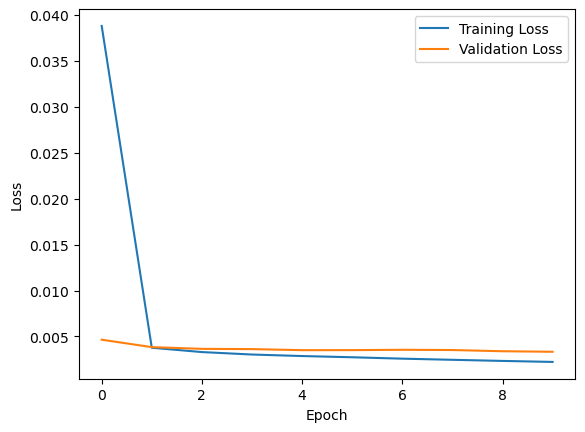

In [26]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluation Metrices on Baseline NN

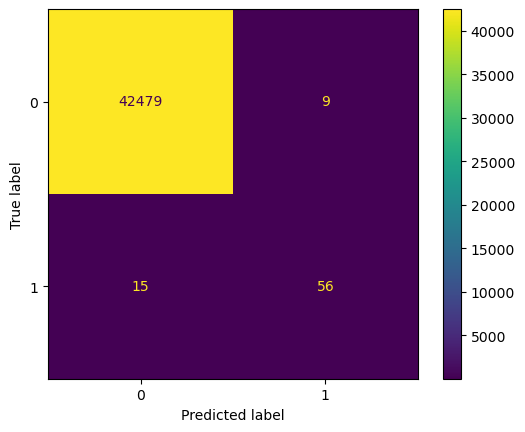

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

In [28]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.86      0.79      0.82        71

    accuracy                           1.00     42559
   macro avg       0.93      0.89      0.91     42559
weighted avg       1.00      1.00      1.00     42559



In [29]:
from sklearn.metrics import roc_auc_score,accuracy_score
print(roc_auc_score(y_test, y_pred_probs))

0.9664803450717485


In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9994360769754929


# Dealing with skewed Dataset

In [31]:
print(y_train.value_counts())

Class
0    198277
1       331
Name: count, dtype: int64


In [32]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
#pay more attention to minority classes
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(class_weight_dict)

{0: np.float64(0.5008346908617742), 1: np.float64(300.012084592145)}


In [33]:
# Training model again after class weight 
history_weighted = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256,
    class_weight=class_weight_dict
)

Epoch 1/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.1470 - val_loss: 0.0816
Epoch 2/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0872 - val_loss: 0.0670
Epoch 3/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0803 - val_loss: 0.0905
Epoch 4/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0719 - val_loss: 0.0716
Epoch 5/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0662 - val_loss: 0.0836
Epoch 6/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0573 - val_loss: 0.0328
Epoch 7/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0571 - val_loss: 0.0610
Epoch 8/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0489 - val_loss: 0.0538
Epoch 9/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0442 - val_loss: 0.0610
Epoch 10/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0410 - val_loss: 0.0467


# Evaluation Metrices on Retrained NN

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Accuracy: 0.9833877675697267
0.9655970799377322
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     42488
           1       0.08      0.86      0.15        71

    accuracy                           0.98     42559
   macro avg       0.54      0.92      0.57     42559
weighted avg       1.00      0.98      0.99     42559



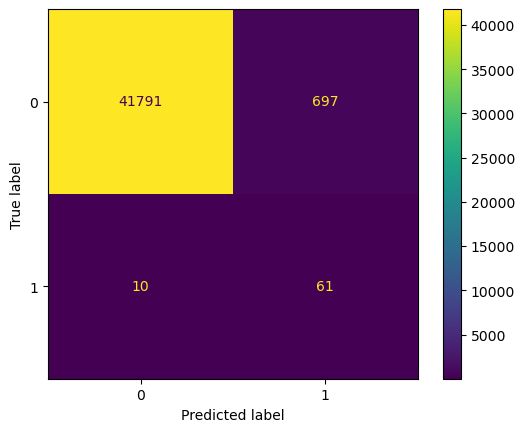

In [34]:
y_pred_probs = tf.sigmoid(model.predict(X_test)).numpy()
y_pred = (y_pred_probs > 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(roc_auc_score(y_test, y_pred_probs))
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()
plt.show()

Result: Recall got high(less missed calls of 1) , Precision got low (more false alarams 1);
the once which are not fraud will be called as fraud now 
class weighting isn't automatically "better", it's a trade-off

Solution:
Better Threshold selection,make model more strict; do high threshold

# Choosing better Threshold (Threshold Tuning)

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step


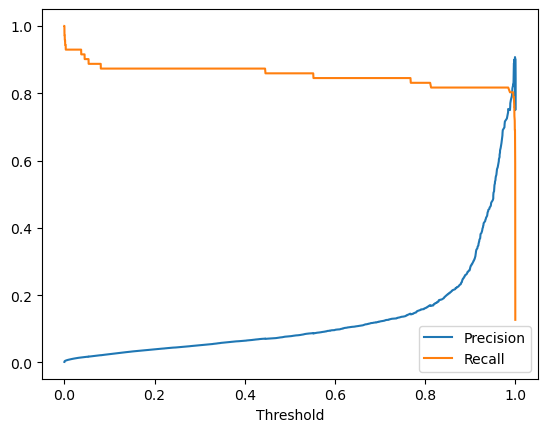

In [35]:
# Get predictions on VALIDATION set
y_val_pred_probs = tf.sigmoid(model.predict(X_val)).numpy()

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_val, y_val_pred_probs)

plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Threshold')
plt.legend()
plt.show()

In [36]:
#selecting a suitbale threshold
from sklearn.metrics import f1_score, precision_score, recall_score

for t in [0.5, 0.7, 0.8, 0.85, 0.9, 0.95, 0.97, 0.98, 0.99, 0.995]:
    y_pred_t = (y_val_pred_probs > t).astype(int)
    f1 = f1_score(y_val, y_pred_t)
    precision = precision_score(y_val, y_pred_t)
    recall = recall_score(y_val, y_pred_t)
    print(f"Threshold {t}: F1 = {f1:.3f}, Precision = {precision:.3f}, Recall = {recall:.3f}")

Threshold 0.5: F1 = 0.143, Precision = 0.078, Recall = 0.859
Threshold 0.7: F1 = 0.213, Precision = 0.122, Recall = 0.845
Threshold 0.8: F1 = 0.270, Precision = 0.161, Recall = 0.831
Threshold 0.85: F1 = 0.324, Precision = 0.202, Recall = 0.817
Threshold 0.9: F1 = 0.419, Precision = 0.282, Recall = 0.817
Threshold 0.95: F1 = 0.607, Precision = 0.483, Recall = 0.817
Threshold 0.97: F1 = 0.730, Precision = 0.659, Recall = 0.817
Threshold 0.98: F1 = 0.768, Precision = 0.725, Recall = 0.817
Threshold 0.99: F1 = 0.792, Precision = 0.781, Recall = 0.803
Threshold 0.995: F1 = 0.814, Precision = 0.826, Recall = 0.803


1330/1330 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.82      0.79      0.81        71

    accuracy                           1.00     42559
   macro avg       0.91      0.89      0.90     42559
weighted avg       1.00      1.00      1.00     42559



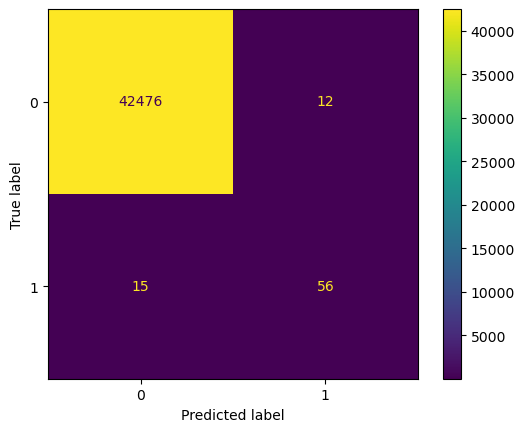

In [37]:
# choose thresold with higehst F1 score 
final_threshold = 0.995 

y_test_pred_probs = tf.sigmoid(model.predict(X_test)).numpy()
y_pred_final = (y_test_pred_probs > final_threshold).astype(int)

print(classification_report(y_test, y_pred_final))
cm = confusion_matrix(y_test, y_pred_final)
ConfusionMatrixDisplay(cm).plot()
plt.show()

Result:
Out of 71 real fraud cases, model catches ~77% while keeping false alarms low (81% of fraud alerts are correct)

If in the project missing fraud is very costly ; prefer more recall ;Low threshold
If false alarams are very costly ; prefer more precision; High Threshold
But best is to get the one with highest F1; It will give you better results; It will balance Recall as well as Precision


# Re Diagnosing Overfitting and underfitting after doing Class weighting 

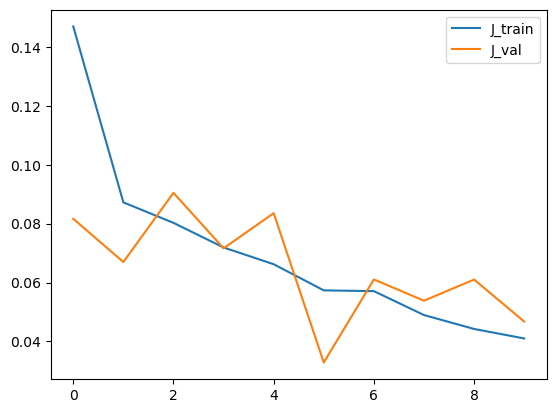

In [38]:
plt.plot(history_weighted.history['loss'], label='J_train')
plt.plot(history_weighted.history['val_loss'], label='J_val')
plt.legend()
plt.show()

Result: class-weighted model is not overfitting or underfitting

# ERROR ANALYSIS

In [39]:
# Take 5-6 rows from test set
sample = X_test.iloc[0:6]   

sample_probs = tf.sigmoid(model.predict(sample)).numpy()
sample_pred = (sample_probs > 0.995).astype(int)

print("Predicted:", sample_pred.flatten())
print("Actual:   ", y_test.iloc[0:6].values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Predicted: [0 0 0 0 0 0]
Actual:    [1 0 0 0 0 0]


In [40]:
fraud_examples = X_test[y_test == 1].iloc[0:5]
fraud_actual = y_test[y_test == 1].iloc[0:5]

fraud_probs = tf.sigmoid(model.predict(fraud_examples)).numpy()
fraud_pred = (fraud_probs > 0.995).astype(int)

print("Predicted:", fraud_pred.flatten())
print("Actual:   ", fraud_actual.values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
Predicted: [0 0 1 1 0]
Actual:    [1 1 1 1 1]


it sometimes misses real fraud to avoid false alarms (that's the trade-off I chose).

In [41]:
print("Predicted probs:", sample_probs.flatten())
print("Predicted class:", sample_pred.flatten())
print("Actual:          ", y_test.iloc[0:6].values)

Predicted probs: [6.290263e-01 3.267296e-04 8.594904e-10 3.192157e-04 8.875355e-05
 6.278597e-04]
Predicted class: [0 0 0 0 0 0]
Actual:           [1 0 0 0 0 0]


In [42]:
print("Predicted probs:", fraud_probs.flatten())
print("Predicted class:", fraud_pred.flatten())
print("Actual:          ", fraud_actual.values)

Predicted probs: [0.6290263  0.05439171 0.9999304  0.9999941  0.97152364]
Predicted class: [0 0 1 1 0]
Actual:           [1 1 1 1 1]


# Baseline NN Model Limitations

-At few places model shows close misses due to strict threshold so we can fix this by changing the threshold = ~0.95 ;but then we will have to accept a few more false alarms (threshold-driven near-misses)


-At a lot predictions there is 0 but should be 1 ;Model gave a low probability (10-48%) to actual fraud( Model gets fooled)

Solution:
More complex architecture

More training data

Try a different model type

More/better features


# More Complex NN with Bigger Architecture

using same threshold

In [43]:
model_big = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1)   
])

model_big.compile(
    optimizer='adam',
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
)

history_big = model_big.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256,
    class_weight=class_weight_dict   # reuse same class weighted weights
)

Epoch 1/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - loss: 0.2240 - val_loss: 0.0549
Epoch 2/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1312 - val_loss: 0.1328
Epoch 3/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1101 - val_loss: 0.0543
Epoch 4/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0834 - val_loss: 0.1179
Epoch 5/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0714 - val_loss: 0.0940
Epoch 6/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0588 - val_loss: 0.0364
Epoch 7/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0647 - val_loss: 0.0679
Epoch 8/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0394 - val_loss: 0.0277
Epoch 9/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0413 - val_loss: 0.0288
Epoch 10/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0387 - val_loss: 0.1987


In [44]:
#find bais and variance 
#Evaluate with same threshold (0.995):
#look fro better trheshold 

# Bias / Varinace Evaluation of Complex NN

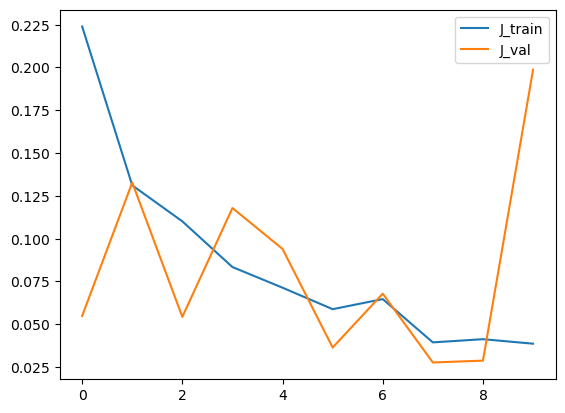

In [45]:
import matplotlib.pyplot as plt
plt.plot(history_big.history['loss'], label='J_train')
plt.plot(history_big.history['val_loss'], label='J_val')
plt.legend()
plt.show()

Overfitting happening.

# L2 Regularization of Overfitted Complex NN

In [49]:
model_big_l2 = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dense(1)
])

model_big_l2.compile(
    optimizer='adam',
    loss=keras.losses.BinaryCrossentropy(from_logits=True),
)

history_big_l2 = model_big_l2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=256,
    class_weight=class_weight_dict
)

Epoch 1/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.3274 - val_loss: 0.1822
Epoch 2/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.2241 - val_loss: 0.2086
Epoch 3/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1928 - val_loss: 0.1661
Epoch 4/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1748 - val_loss: 0.1227
Epoch 5/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1596 - val_loss: 0.1956
Epoch 6/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1514 - val_loss: 0.1287
Epoch 7/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.1315 - val_loss: 0.1764
Epoch 8/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1274 - val_loss: 0.1244
Epoch 9/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.1175 - val_loss: 0.1265
Epoch 10/10
776/776 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1088 - val_loss: 0.1640


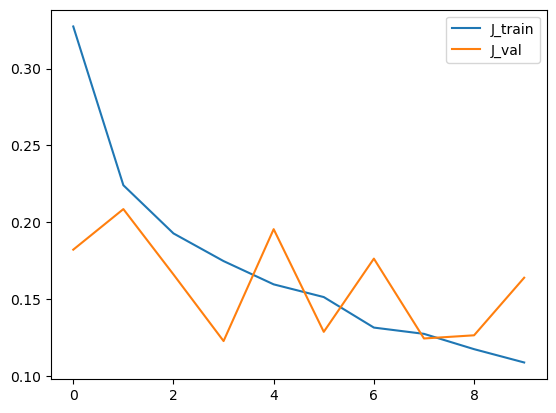

In [50]:
plt.plot(history_big_l2.history['loss'], label='J_train')
plt.plot(history_big_l2.history['val_loss'], label='J_val')
plt.legend()
plt.show()

Result :L2 helped — the severe overfitting is fixed. Not perfectly smooth, but much more stable than before.

# Tuning Threshold for Complex NN

In [52]:
y_val_probs_l2 = tf.sigmoid(model_big_l2.predict(X_val)).numpy()

for t in [0.5, 0.7, 0.85, 0.9, 0.95, 0.97, 0.98, 0.99, 0.995, 0.997, 0.998, 0.999]:
    y_pred_t = (y_val_probs_l2 > t).astype(int)
    f1 = f1_score(y_val, y_pred_t)
    print(f"Threshold {t}: F1 = {f1:.3f}")

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
Threshold 0.5: F1 = 0.060
Threshold 0.7: F1 = 0.082
Threshold 0.85: F1 = 0.134
Threshold 0.9: F1 = 0.188
Threshold 0.95: F1 = 0.377
Threshold 0.97: F1 = 0.570
Threshold 0.98: F1 = 0.691
Threshold 0.99: F1 = 0.753
Threshold 0.995: F1 = 0.758
Threshold 0.997: F1 = 0.744
Threshold 0.998: F1 = 0.710
Threshold 0.999: F1 = 0.695


So 0.995 is the best threshold for this L2 model too. As we increase the threshold, we're making the model more strict about predicting Class 1.

In [53]:
final_threshold_l2 = 0.995

y_test_probs_l2 = tf.sigmoid(model_big_l2.predict(X_test)).numpy()
y_pred_l2 = (y_test_probs_l2 > final_threshold_l2).astype(int)

print(classification_report(y_test, y_pred_l2))

1330/1330 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42488
           1       0.80      0.77      0.79        71

    accuracy                           1.00     42559
   macro avg       0.90      0.89      0.89     42559
weighted avg       1.00      1.00      1.00     42559



In [ ]:
RESULT:
more complexity needed more regularization just to match the simple model

In [56]:
sample = X_test.iloc[0:6]

sample_probs = tf.sigmoid(model_big_l2.predict(sample)).numpy()
sample_pred = (sample_probs > final_threshold_l2).astype(int)

print("Predicted:", sample_pred.flatten())
print("Actual:   ", y_test.iloc[0:6].values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
Predicted: [0 0 0 0 0 0]
Actual:    [1 0 0 0 0 0]


In [57]:
fraud_examples = X_test[y_test == 1].iloc[0:5]
fraud_actual = y_test[y_test == 1].iloc[0:5]

fraud_probs = tf.sigmoid(model_big_l2.predict(fraud_examples)).numpy()
fraud_pred = (fraud_probs > final_threshold_l2).astype(int)

print("Predicted:", fraud_pred.flatten())
print("Actual:   ", fraud_actual.values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Predicted: [0 0 1 1 0]
Actual:    [1 1 1 1 1]


In [58]:
import joblib
model_big_l2.save('fraud_model.keras')
joblib.dump(scaler, 'fraud_scaler.pkl')

print("Model and scaler saved.")

Model and scaler saved.
